Necessary to install dependencies:

```bash
conda create -n phi-finder python==3.11

conda activate phi-finder

pip install -e .[dev,test] --no-cache-dir

conda install -c conda-forge tesseract

conda install -c conda-forge pytesseract   
```

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"]=""  # CPU only.

In [2]:
import pydicom as dicom
import matplotlib.pyplot as plt
import pandas as pd
from presidio_image_redactor import DicomImageRedactorEngine

from phi_finder.dicom_tools import anonymise_dicom

/home/pedro/miniconda3/envs/phi-finder/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
!wget -nc https://github.com/microsoft/presidio/raw/refs/heads/main/docs/samples/python/sample_data/0_ORIGINAL.dcm

File ‘0_ORIGINAL.dcm’ already there; not retrieving.



In [4]:
def compare_dicom_images(
    instance_original: dicom.dataset.FileDataset,
    instance_redacted: dicom.dataset.FileDataset,
    figsize: tuple = (11, 11)
) -> None:
    """Display the DICOM pixel arrays of both original and redacted as images.

    Args:
        instance_original (dicom.dataset.FileDataset): A single DICOM instance (with text PHI).
        instance_redacted (dicom.dataset.FileDataset): A single DICOM instance (redacted PHI).
        figsize (tuple): Figure size in inches (width, height).
    """
    _, ax = plt.subplots(1, 2, figsize=figsize)
    ax[0].imshow(instance_original.pixel_array, cmap="gray")
    ax[0].set_title('Original')
    ax[1].imshow(instance_redacted.pixel_array, cmap="gray")
    ax[1].set_title('Redacted')

Our current default behaviour only work over the headers; we set all pixels to 0.

(0008, 0008)


/home/pedro/miniconda3/envs/phi-finder/lib/python3.11/site-packages/pydicom/valuerep.py:443: UserWarning: Invalid value for VR DA: '[XXXX]'.
  warnings.warn(msg)
/home/pedro/miniconda3/envs/phi-finder/lib/python3.11/site-packages/pydicom/valuerep.py:443: UserWarning: Invalid value for VR CS: '[XXXX]'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warnings.warn(msg)
/home/pedro/miniconda3/envs/phi-finder/lib/python3.11/site-packages/pydicom/valuerep.py:443: UserWarning: Invalid value for VR AS: '[XXXX]'.
  warnings.warn(msg)


(7fe0, 0010)


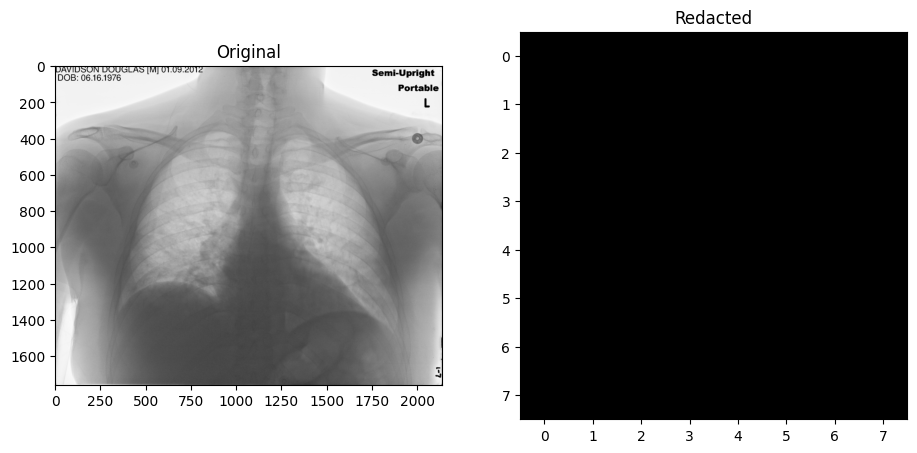

In [5]:
sample_dcm = dicom.dcmread("0_ORIGINAL.dcm")
analyser = anonymise_dicom._build_presidio_analyser(score_threshold=0.5)
anonymised_dcm = anonymise_dicom.anonymise_image(sample_dcm.copy(), analyser, image_redactor=None)
anonymised_dcm = anonymise_dicom.destroy_pixels(ds=anonymised_dcm)
compare_dicom_images(sample_dcm, anonymised_dcm)

Comparing the headers, we see that several entries were changed to [XXXX]

In [6]:
df_redacted = pd.DataFrame(anonymised_dcm.values())
df_redacted[0] = df_redacted[0].apply(lambda x: dicom.dataelem.DataElement_from_raw(x) if isinstance(x, dicom.dataelem.RawDataElement) else x)
df_redacted['name'] = df_redacted[0].apply(lambda x: x.name)
df_redacted['value'] = df_redacted[0].apply(lambda x: x.value)
df_redacted = df_redacted[['name', 'value']]
print("Patient's Name",df_redacted[df_redacted['name'] == "Patient's Name"].value.item())
print("Patient ID",df_redacted[df_redacted['name'] == "Patient ID"].value.item())
print("Patient's Birth Date",df_redacted[df_redacted['name'] == "Patient's Birth Date"].value.item())
print("Patient's Age",df_redacted[df_redacted['name'] == "Patient's Age"].value.item())
print("Patient's Sex",df_redacted[df_redacted['name'] == "Patient's Sex"].value.item())
print("Acquisition Device Processing Description",df_redacted[df_redacted['name'] == "Acquisition Device Processing Description"].value.item())
print("Body Part Examined",df_redacted[df_redacted['name'] == "Body Part Examined"].value.item())


Patient's Name XXXX
Patient ID [XXXX]
Patient's Birth Date [XXXX]
Patient's Age [XXXX]
Patient's Sex [XXXX]
Acquisition Device Processing Description CHEST AP PORT X-WISE GRID
Body Part Examined CHEST


We can also remove the burned-in pixels with one extra argument to anonymise_image. 

See below:

(0008, 0008)
(7fe0, 0010)


/home/pedro/miniconda3/envs/phi-finder/lib/python3.11/site-packages/pydicom/valuerep.py:443: UserWarning: Invalid value for VR DA: '[XXXX]'.
  warnings.warn(msg)
/home/pedro/miniconda3/envs/phi-finder/lib/python3.11/site-packages/pydicom/valuerep.py:443: UserWarning: Invalid value for VR CS: '[XXXX]'. Please see <https://dicom.nema.org/medical/dicom/current/output/html/part05.html#table_6.2-1> for allowed values for each VR.
  warnings.warn(msg)
/home/pedro/miniconda3/envs/phi-finder/lib/python3.11/site-packages/pydicom/valuerep.py:443: UserWarning: Invalid value for VR AS: '[XXXX]'.
  warnings.warn(msg)


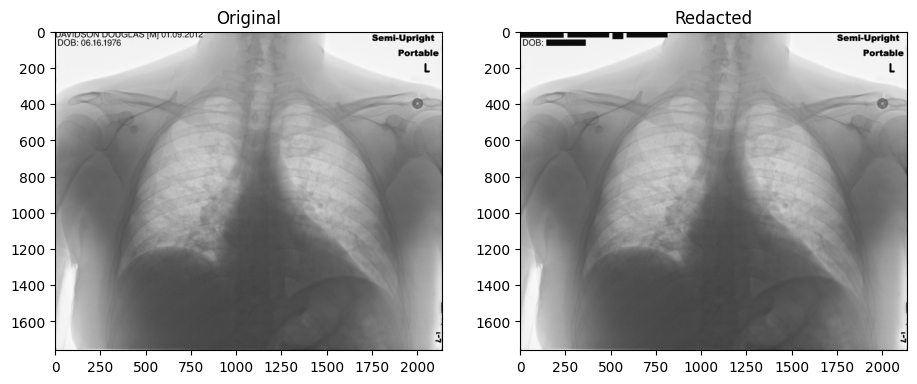

In [7]:
anonymised_dcm = anonymise_dicom.anonymise_image(sample_dcm.copy(), analyser, image_redactor=DicomImageRedactorEngine())
compare_dicom_images(sample_dcm, anonymised_dcm)